In [1]:
from google.colab import files
import pandas as pd

# Upload CSV
uploaded = files.upload()

# Load into DataFrame (adjust the filename if needed)
df = pd.read_csv("heards_structured_cleaned_v11.csv")


Saving heards_structured_cleaned_v11.csv to heards_structured_cleaned_v11.csv


In [5]:
from google.colab import files
import pandas as pd

# Upload both files
uploaded = files.upload()


Saving CI_SymbolPrice_2025-06-02T030821Z.csv to CI_SymbolPrice_2025-06-02T030821Z.csv
Saving CI_SymbolPrice_2025-06-02T030407Z.csv to CI_SymbolPrice_2025-06-02T030407Z.csv


In [6]:
# MOPS 180 (CI_SymbolPrice_2025-06-02T030821Z.csv)
df_mops180_actual = pd.read_csv("CI_SymbolPrice_2025-06-02T030821Z.csv")

# Rename and clean
df_mops180_actual = df_mops180_actual.rename(columns={
    "Description": "Date",
    "FO 180 CST 3.5%S FOB Spore Cargo": "Close"
})
df_mops180_actual = df_mops180_actual[~df_mops180_actual['Date'].str.contains("Currency|Symbol|Bate", na=False)]
df_mops180_actual['Date'] = pd.to_datetime(df_mops180_actual['Date'])
df_mops180_actual['Close'] = pd.to_numeric(df_mops180_actual['Close'], errors='coerce')

# Weekly average
weekly_actual_180 = df_mops180_actual.set_index('Date')['Close'].resample('W').mean()


In [7]:
# MOPS 380 (CI_SymbolPrice_2025-06-02T030407Z.csv)
df_mops380_actual = pd.read_csv("CI_SymbolPrice_2025-06-02T030407Z.csv")

# Rename and clean
df_mops380_actual = df_mops380_actual.rename(columns={
    "Description": "Date",
    "FO 380 CST 3.5%S FOB Spore Cargo": "Close"
})
df_mops380_actual = df_mops380_actual[~df_mops380_actual['Date'].str.contains("Currency|Symbol|Bate", na=False)]
df_mops380_actual['Date'] = pd.to_datetime(df_mops380_actual['Date'])
df_mops380_actual['Close'] = pd.to_numeric(df_mops380_actual['Close'], errors='coerce')

# Weekly average
weekly_actual_380 = df_mops380_actual.set_index('Date')['Close'].resample('W').mean()


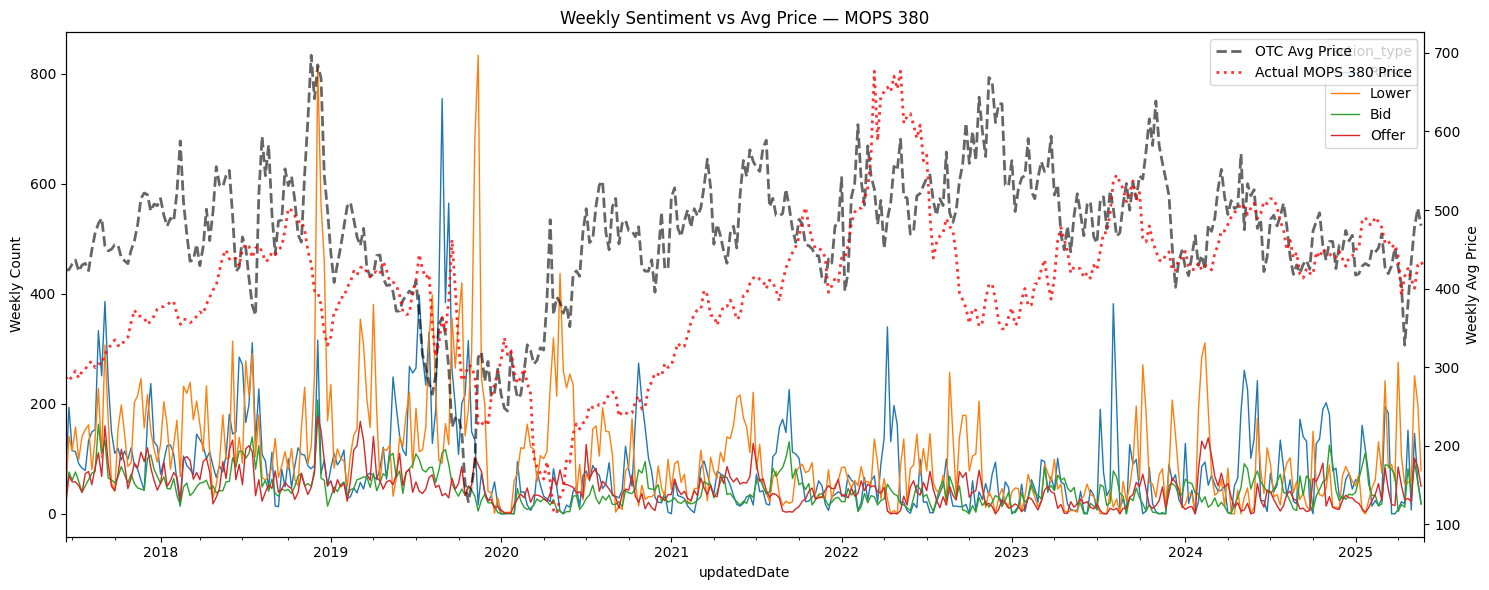

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter for MOPS 380 and convert index to datetime
df_mops380 = df[df['price_basis'] == 'MOPS 380'][['price', 'action_type']]
df_mops380.index = pd.to_datetime(df_mops380.index)

# Weekly sentiment counts and OTC price
weekly_counts_380 = df_mops380.groupby([pd.Grouper(freq='W'), 'action_type']).size().unstack(fill_value=0)
weekly_price_380 = df_mops380['price'].resample('W').mean()
summary_380 = weekly_counts_380.copy()
summary_380['avg_price'] = weekly_price_380

# === Load actual MOPS 380 data ===
df_actual_380 = pd.read_csv("CI_SymbolPrice_2025-06-02T030407Z.csv")
df_actual_380 = df_actual_380.rename(columns={
    "Description": "Date",
    "FO 380 CST 3.5%S FOB Spore Cargo": "Close"
})
df_actual_380 = df_actual_380[~df_actual_380['Date'].str.contains("Currency|Symbol|Bate", na=False)]
df_actual_380['Date'] = pd.to_datetime(df_actual_380['Date'])
df_actual_380['Close'] = pd.to_numeric(df_actual_380['Close'], errors='coerce')
weekly_actual_380 = df_actual_380.set_index('Date')['Close'].resample('W').mean()

# === Trim actual data to match OTC starting date ===
start_date = df_mops380.index.min()
weekly_actual_380_trimmed = weekly_actual_380[weekly_actual_380.index >= start_date]

# === Plot ===
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot sentiment action counts
summary_380[['Raise', 'Lower', 'Bid', 'Offer']].plot(ax=ax1, linewidth=1)
ax1.set_ylabel("Weekly Count")
ax1.set_title("Weekly Sentiment vs Avg Price — MOPS 380")

# Plot OTC price and actual price on secondary y-axis
ax2 = ax1.twinx()
summary_380['avg_price'].plot(
    ax=ax2, color='black', linestyle='--', linewidth=2, alpha=0.6, label='OTC Avg Price'
)
weekly_actual_380_trimmed.plot(
    ax=ax2, color='red', linestyle=':', linewidth=2, alpha=0.8, label='Actual MOPS 380 Price'
)

ax2.set_ylabel("Weekly Avg Price")
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


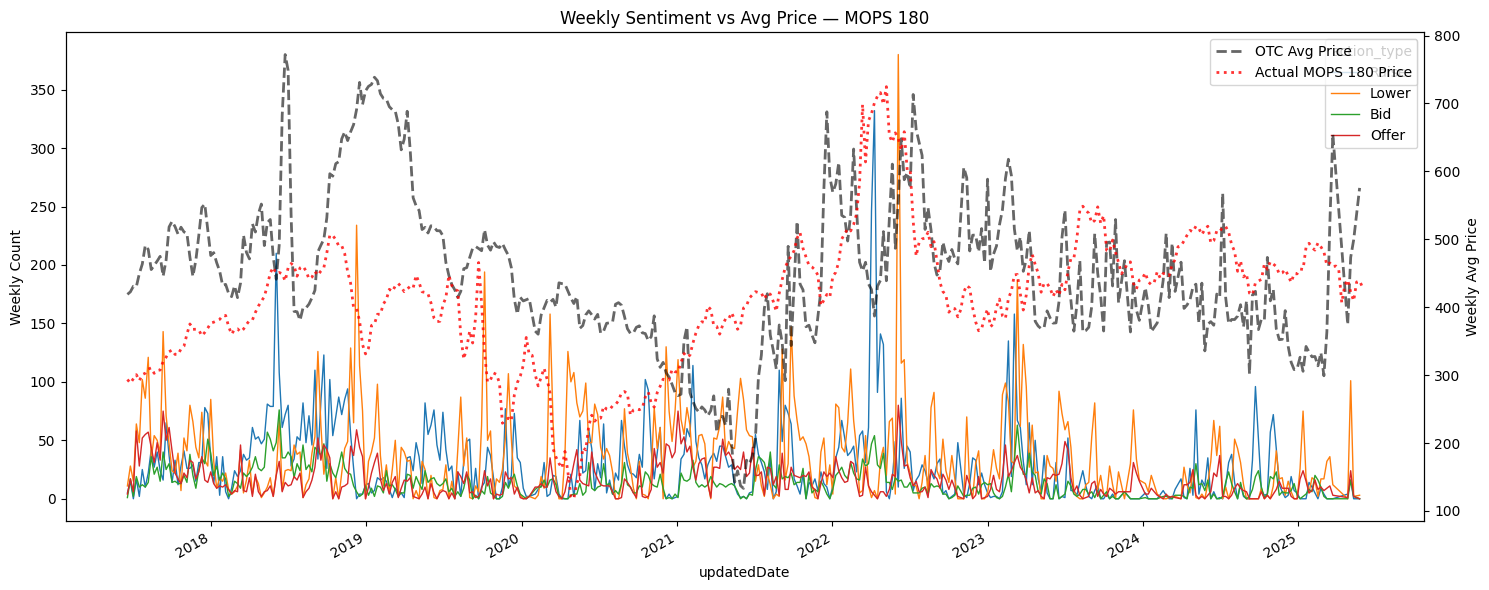

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter for MOPS 180 and convert index to datetime
df_mops180 = df[df['price_basis'] == 'MOPS 180'][['price', 'action_type']]
df_mops180.index = pd.to_datetime(df_mops180.index)

# Weekly sentiment counts and OTC price
weekly_counts_180 = df_mops180.groupby([pd.Grouper(freq='W'), 'action_type']).size().unstack(fill_value=0)
weekly_price_180 = df_mops180['price'].resample('W').mean()
summary_180 = weekly_counts_180.copy()
summary_180['avg_price'] = weekly_price_180

# === Load actual MOPS 180 data ===
df_actual_180 = pd.read_csv("CI_SymbolPrice_2025-06-02T030821Z.csv")  # MOPS 180
df_actual_180 = df_actual_180.rename(columns={
    "Description": "Date",
    "FO 180 CST 3.5%S FOB Spore Cargo": "Close"
})
df_actual_180 = df_actual_180[~df_actual_180['Date'].str.contains("Currency|Symbol|Bate", na=False)]
df_actual_180['Date'] = pd.to_datetime(df_actual_180['Date'])
df_actual_180['Close'] = pd.to_numeric(df_actual_180['Close'], errors='coerce')
weekly_actual_180 = df_actual_180.set_index('Date')['Close'].resample('W').mean()

# === Trim actual data to match OTC start ===
start_date_180 = df_mops180.index.min()
weekly_actual_180_trimmed = weekly_actual_180[weekly_actual_180.index >= start_date_180]

# === Plot ===
fig, ax1 = plt.subplots(figsize=(15, 6))

# Sentiment action counts
summary_180[['Raise', 'Lower', 'Bid', 'Offer']].plot(ax=ax1, linewidth=1)
ax1.set_ylabel("Weekly Count")
ax1.set_title("Weekly Sentiment vs Avg Price — MOPS 180")

# OTC and actual prices on secondary y-axis
ax2 = ax1.twinx()
summary_180['avg_price'].plot(
    ax=ax2, color='black', linestyle='--', linewidth=2, alpha=0.6, label='OTC Avg Price'
)
weekly_actual_180_trimmed.plot(
    ax=ax2, color='red', linestyle=':', linewidth=2, alpha=0.8, label='Actual MOPS 180 Price'
)

ax2.set_ylabel("Weekly Avg Price")
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


# 📈 MOPS 180 – Time Series Correlation Analysis

## Objective
To explore whether sentiment-based features (Raise, Lower, Bid, Offer) from HEARDS data are predictive of or reactive to the actual benchmark price (MOPS 180) or OTC price.

---

## 1. Dataset Overview

- **HEARDS Dataset**  
  Contains OTC sentiment features (`action_type`), `price`, and other trade metadata.

- **Benchmark Price Dataset**  
  `CI_SymbolPrice_2025-06-02T030821Z.csv` — contains official HSFO 180 price time series based on MOPS.

---

## 2. Focused Metrics

- **Sentiment Features (Weekly Aggregates)**  
  - `Raise`, `Lower`, `Bid`, `Offer` → Weekly counts

- **Target Price Series**  
  - **OTC Price** from HEARDS (filtered for MOPS 180)  
  - **Actual Price** from benchmark data (MOPS 180)

---

## 3. Methodology

1. Filter `price_basis == 'MOPS 180'` from HEARDS.
2. Aggregate sentiment features by week.
3. Resample OTC and actual price series to weekly averages.
4. Standardize time series (z-scores) for fair comparison.
5. Compute lagged correlation:
    - Lag range: **-5 to +5 weeks**
    - Positive lag: Sentiment **leads** price (predictive)
    - Negative lag: Price **leads** sentiment (reactive)
6. Plot correlation vs. lag for each action type and both price types.

---

## 4. Key Questions

- Do any sentiment types (e.g., `Raise`, `Lower`) show **leading correlation** with price?
- Is the OTC price reacting to actual price changes, or vice versa?
- Which has stronger correlation: OTC or benchmark price?

---

## 5. Next Steps (Post-MOPS 180)

- Repeat for **MOPS 380**
- Compare results across benchmarks
- Consider additional feature interactions (volume, party, location)


In [22]:
import pandas as pd

# === Load HEARDS dataset ===
df = pd.read_csv("/content/heards_structured_cleaned_v11.csv", parse_dates=["updatedDate"])

# === Filter for MOPS 180 ===
df_180 = df[df["price_basis"] == "MOPS 180"].copy()
df_180["updatedDate"] = pd.to_datetime(df_180["updatedDate"])
df_180.set_index("updatedDate", inplace=True)

# === Weekly Sentiment Count ===
weekly_sentiment_180 = df_180.groupby([pd.Grouper(freq='W'), 'action_type']).size().unstack(fill_value=0)

# === Weekly OTC Price ===
weekly_otc_price_180 = df_180["price"].resample("W").mean().rename("otc_price")

# === Merge sentiment + OTC price ===
weekly_180 = pd.concat([weekly_sentiment_180, weekly_otc_price_180], axis=1)

weekly_180.head()


,Bid,Lower,Offer,Raise,otc_price
updatedDate,,,,,
2017-06-18,1.0,11.0,4.0,5.0,418.890952
2017-06-25,17.0,28.0,17.0,15.0,422.643636
2017-07-02,2.0,15.0,6.0,0.0,430.874348
2017-07-09,19.0,64.0,58.0,17.0,430.176612
2017-07-16,10.0,48.0,28.0,2.0,449.329545


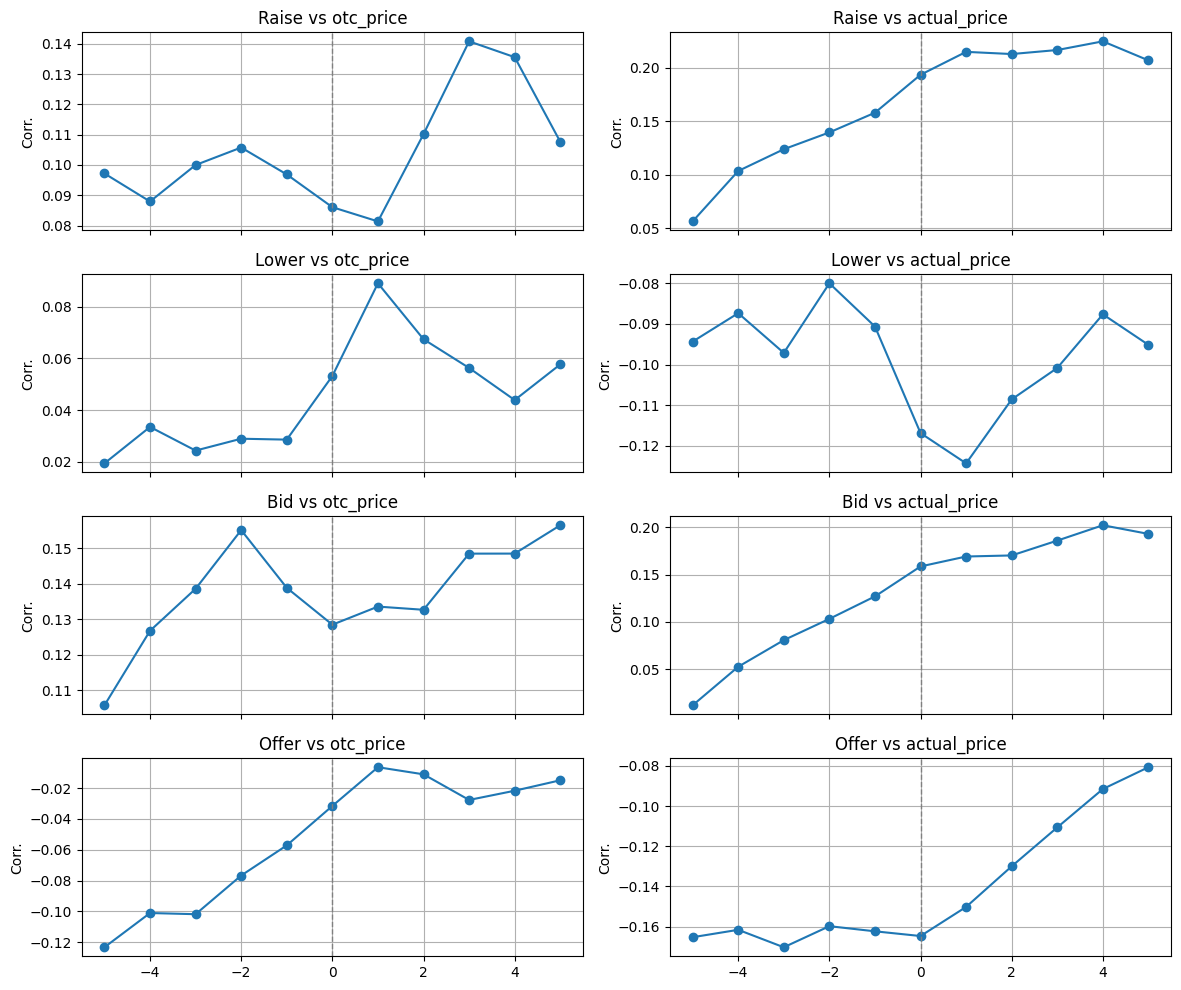

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# === Standardize time series (Z-scores) ===
def zscore(series):
    return (series - series.mean()) / series.std()

# Standardize all columns
weekly_180_z = weekly_180.copy()
weekly_180_z = weekly_180_z.apply(zscore)

# Merge in actual MOPS 180 price (already weekly and trimmed)
weekly_combined = weekly_180_z.copy()
weekly_combined['actual_price'] = weekly_actual_180_trimmed.loc[weekly_combined.index]

# === Lagged correlation function ===
def compute_lagged_corr(df, feature, target, max_lag=5):
    lags = range(-max_lag, max_lag + 1)
    correlations = []
    for lag in lags:
        shifted = df[feature].shift(lag)
        corr = shifted.corr(df[target])
        correlations.append(corr)
    return lags, correlations

# === Run and plot ===
action_types = ['Raise', 'Lower', 'Bid', 'Offer']
target_prices = ['otc_price', 'actual_price']

fig, axes = plt.subplots(len(action_types), len(target_prices), figsize=(12, 10), sharex=True)

for i, action in enumerate(action_types):
    for j, target in enumerate(target_prices):
        lags, corrs = compute_lagged_corr(weekly_combined, action, target)
        axes[i, j].plot(lags, corrs, marker='o')
        axes[i, j].axvline(0, color='gray', linestyle='--', linewidth=1)
        axes[i, j].set_title(f'{action} vs {target}')
        axes[i, j].set_ylabel('Corr.')
        axes[i, j].grid(True)

plt.tight_layout()
plt.show()


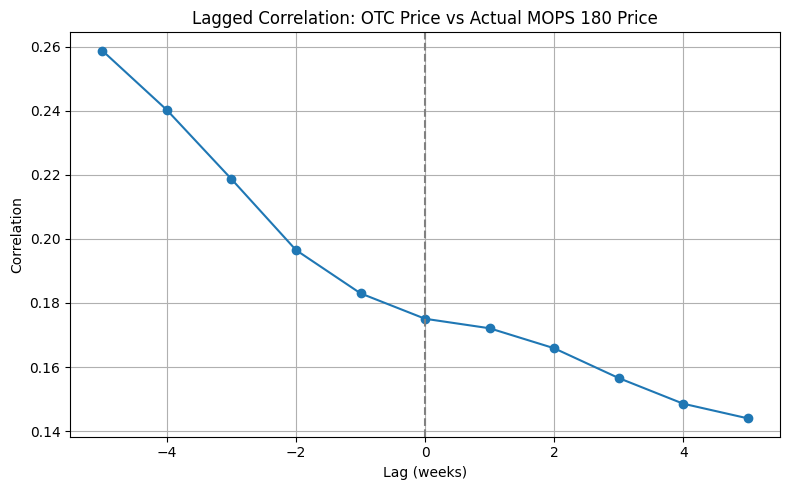

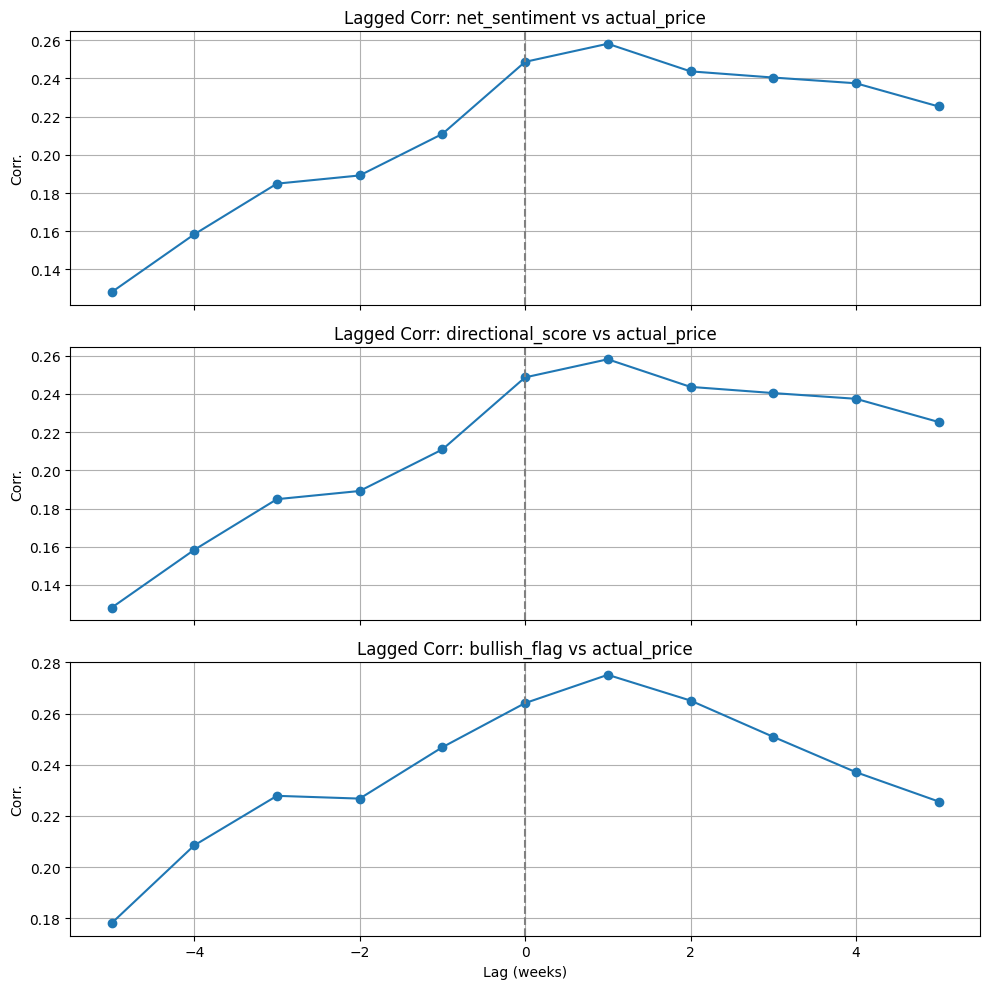

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Utility: Z-score standardization ===
def zscore(series):
    return (series - series.mean()) / series.std()

# === Lagged correlation function ===
def compute_lagged_corr(df, feature, target, max_lag=5):
    lags = range(-max_lag, max_lag + 1)
    correlations = []
    for lag in lags:
        shifted = df[feature].shift(lag)
        corr = shifted.corr(df[target])
        correlations.append(corr)
    return list(lags), correlations

# === 1. OTC vs Actual Price Lagged Correlation ===
weekly_otc_trimmed = weekly_180_z["otc_price"]
weekly_actual_trimmed = weekly_actual_180_trimmed.loc[weekly_180_z.index]
combined_price_df = pd.concat([weekly_otc_trimmed, weekly_actual_trimmed], axis=1).dropna()
combined_price_df.columns = ["otc_price", "actual_price"]

lags, corrs = compute_lagged_corr(combined_price_df, "otc_price", "actual_price")

plt.figure(figsize=(8, 5))
plt.plot(lags, corrs, marker='o')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Lagged Correlation: OTC Price vs Actual MOPS 180 Price")
plt.xlabel("Lag (weeks)")
plt.ylabel("Correlation")
plt.grid(True)
plt.tight_layout()
plt.show()

# === 2. Create Composite Sentiment Features ===
weekly_combined['net_sentiment'] = (
    weekly_combined['Raise'] + weekly_combined['Bid'] -
    weekly_combined['Lower'] - weekly_combined['Offer']
)

weekly_combined['directional_score'] = (
    zscore(weekly_combined['Raise']) +
    zscore(weekly_combined['Bid']) -
    zscore(weekly_combined['Lower']) -
    zscore(weekly_combined['Offer'])
)

weekly_combined['bullish_flag'] = (
    (zscore(weekly_combined['Raise']) > 1) &
    (zscore(weekly_combined['Bid']) > 1) &
    (zscore(weekly_combined['Offer']) < -0.5)
).astype(int)

# === 3. Correlate Composite Features with Actual Price ===
composite_features = ['net_sentiment', 'directional_score', 'bullish_flag']

fig, axes = plt.subplots(len(composite_features), 1, figsize=(10, 10), sharex=True)

for i, feature in enumerate(composite_features):
    lags, corrs = compute_lagged_corr(weekly_combined, feature, "actual_price")
    axes[i].plot(lags, corrs, marker='o')
    axes[i].axvline(0, color='gray', linestyle='--')
    axes[i].set_title(f"Lagged Corr: {feature} vs actual_price")
    axes[i].set_ylabel("Corr.")
    axes[i].grid(True)

plt.xlabel("Lag (weeks)")
plt.tight_layout()
plt.show()


In [26]:
import pandas as pd
import numpy as np

# === Redefine lagged correlation function ===
def compute_lagged_corr(df, feature, target, max_lag=5):
    lags = range(-max_lag, max_lag + 1)
    correlations = []
    for lag in lags:
        shifted = df[feature].shift(lag)
        corr = shifted.corr(df[target])
        correlations.append(corr)
    return list(lags), correlations

# === Compute correlations ===
lags = list(range(-5, 6))

otc_vs_actual_corrs = compute_lagged_corr(combined_price_df, "otc_price", "actual_price")
raise_vs_actual = compute_lagged_corr(weekly_combined, "Raise", "actual_price")
lower_vs_actual = compute_lagged_corr(weekly_combined, "Lower", "actual_price")
bid_vs_actual = compute_lagged_corr(weekly_combined, "Bid", "actual_price")
offer_vs_actual = compute_lagged_corr(weekly_combined, "Offer", "actual_price")
net_sentiment_corrs = compute_lagged_corr(weekly_combined, "net_sentiment", "actual_price")
directional_score_corrs = compute_lagged_corr(weekly_combined, "directional_score", "actual_price")
bullish_flag_corrs = compute_lagged_corr(weekly_combined, "bullish_flag", "actual_price")

# === Assemble correlation table ===
corr_table = pd.DataFrame({
    "Lag (weeks)": lags,
    "OTC vs Actual": otc_vs_actual_corrs[1],
    "Raise vs Actual": raise_vs_actual[1],
    "Lower vs Actual": lower_vs_actual[1],
    "Bid vs Actual": bid_vs_actual[1],
    "Offer vs Actual": offer_vs_actual[1],
    "Net Sentiment vs Actual": net_sentiment_corrs[1],
    "Directional Score vs Actual": directional_score_corrs[1],
    "Bullish Flag vs Actual": bullish_flag_corrs[1]
})

# === Display the table ===
corr_table.round(3)  # Rounded for readability


,Lag (weeks),OTC vs Actual,Raise vs Actual,Lower vs Actual,Bid vs Actual,Offer vs Actual,Net Sentiment vs Actual,Directional Score vs Actual,Bullish Flag vs Actual
0,-5,0.259,0.056,-0.094,0.012,-0.165,0.128,0.128,0.178
1,-4,0.240,0.103,-0.087,0.053,-0.162,0.158,0.158,0.208
2,-3,0.219,0.124,-0.097,0.081,-0.170,0.185,0.185,0.228
3,-2,0.197,0.140,-0.080,0.103,-0.160,0.189,0.189,0.227
4,-1,0.183,0.158,-0.091,0.127,-0.162,0.211,0.211,0.247
5,0,0.175,0.194,-0.117,0.159,-0.165,0.249,0.249,0.264
6,1,0.172,0.215,-0.124,0.169,-0.150,0.258,0.258,0.275
7,2,0.166,0.213,-0.109,0.170,-0.130,0.244,0.244,0.265
8,3,0.157,0.217,-0.101,0.186,-0.111,0.240,0.240,0.251
9,4,0.149,0.225,-0.088,0.202,-0.092,0.237,0.237,0.237


In [27]:
import pandas as pd

# === Original lagged correlation data ===
data = {
    "Lag (weeks)": list(range(-5, 6)),
    "OTC vs Actual": [0.259, 0.240, 0.219, 0.197, 0.183, 0.175, 0.172, 0.166, 0.157, 0.149, 0.144],
    "Raise vs Actual": [0.056, 0.103, 0.124, 0.140, 0.158, 0.194, 0.215, 0.213, 0.217, 0.225, 0.207],
    "Lower vs Actual": [-0.094, -0.087, -0.097, -0.080, -0.091, -0.117, -0.124, -0.109, -0.101, -0.088, -0.095],
    "Bid vs Actual": [0.012, 0.053, 0.081, 0.103, 0.127, 0.159, 0.169, 0.170, 0.186, 0.202, 0.193],
    "Offer vs Actual": [-0.165, -0.162, -0.170, -0.160, -0.162, -0.165, -0.150, -0.130, -0.111, -0.092, -0.081],
    "Net Sentiment vs Actual": [0.128, 0.158, 0.185, 0.189, 0.211, 0.249, 0.258, 0.244, 0.240, 0.237, 0.225],
    "Directional Score vs Actual": [0.128, 0.158, 0.185, 0.189, 0.211, 0.249, 0.258, 0.244, 0.240, 0.237, 0.225],
    "Bullish Flag vs Actual": [0.178, 0.208, 0.228, 0.227, 0.247, 0.264, 0.275, 0.265, 0.251, 0.237, 0.226]
}

df_corr = pd.DataFrame(data)

# === Calculate max correlation from lag +1 to +3 ===
lag_leads = df_corr[df_corr["Lag (weeks)"].isin([1, 2, 3])]
rankings = []

for column in df_corr.columns[1:]:
    max_corr = lag_leads[column].max()
    best_lag = lag_leads.loc[lag_leads[column].idxmax(), "Lag (weeks)"]
    rankings.append((column, max_corr, best_lag))

# === Create ranking table ===
ranking_df = pd.DataFrame(rankings, columns=["Feature", "Max Correlation (Lag +1 to +3)", "Best Lag"])
ranking_df = ranking_df.sort_values(by="Max Correlation (Lag +1 to +3)", ascending=False).reset_index(drop=True)
ranking_df.index += 1

# === Display the table ===
print(ranking_df.to_string())


                       Feature  Max Correlation (Lag +1 to +3)  Best Lag
1       Bullish Flag vs Actual                           0.275         1
2      Net Sentiment vs Actual                           0.258         1
3  Directional Score vs Actual                           0.258         1
4              Raise vs Actual                           0.217         3
5                Bid vs Actual                           0.186         3
6                OTC vs Actual                           0.172         1
7              Lower vs Actual                          -0.101         3
8              Offer vs Actual                          -0.111         3


# 🔍 MOPS 380 Correlation Analysis

## 1. Objective
Replicate the MOPS 180 analysis process for **MOPS 380** to identify:
- Correlation between OTC prices and actual benchmark prices.
- Lagged relationships between action-type sentiment features (e.g., Raise, Lower, Bid, Offer) and MOPS 380 price.
- Construction and evaluation of engineered sentiment signals (Bullish Flag, Net Sentiment, Directional Score).

---

## 2. Steps

### 📥 Step 1: Load and clean actual MOPS 380 benchmark price data
- Extract `Close` price for FO 380 CST 3.5%S FOB Spore Cargo.
- Drop header/meta rows.
- Parse dates and convert prices to numeric.
- Resample to weekly average.

### 🔧 Step 2: Extract and resample OTC price data for MOPS 380
- Filter dataset by `price_basis = MOPS 380`.
- Resample to weekly average OTC price.

### 🔄 Step 3: Generate action-type counts weekly
- Group by week and count: Raise, Lower, Bid, Offer.
- Compute derived features: Net Sentiment, Directional Score, Bullish Flag.

### 📈 Step 4: Lagged correlation analysis
- Evaluate Pearson correlation between actual price and each feature.
- Test lags from -5 to +5 weeks.
- Identify lead/lag behavior (predictive potential).

### 📊 Step 5: Tabulate and rank
- Create summary table showing max correlation and best lag.
- Rank features as leading indicators.

---

## 3. Goals
- Check consistency: do we observe similar patterns as in MOPS 180?
- Identify stronger or weaker signals.
- Decide whether to combine both bases for unified model development.

---

## ✅ Next Steps After This
- Begin exploring Granger causality or VAR for multivariate relationships.
- Incorporate all benchmark types into one unified strategy.


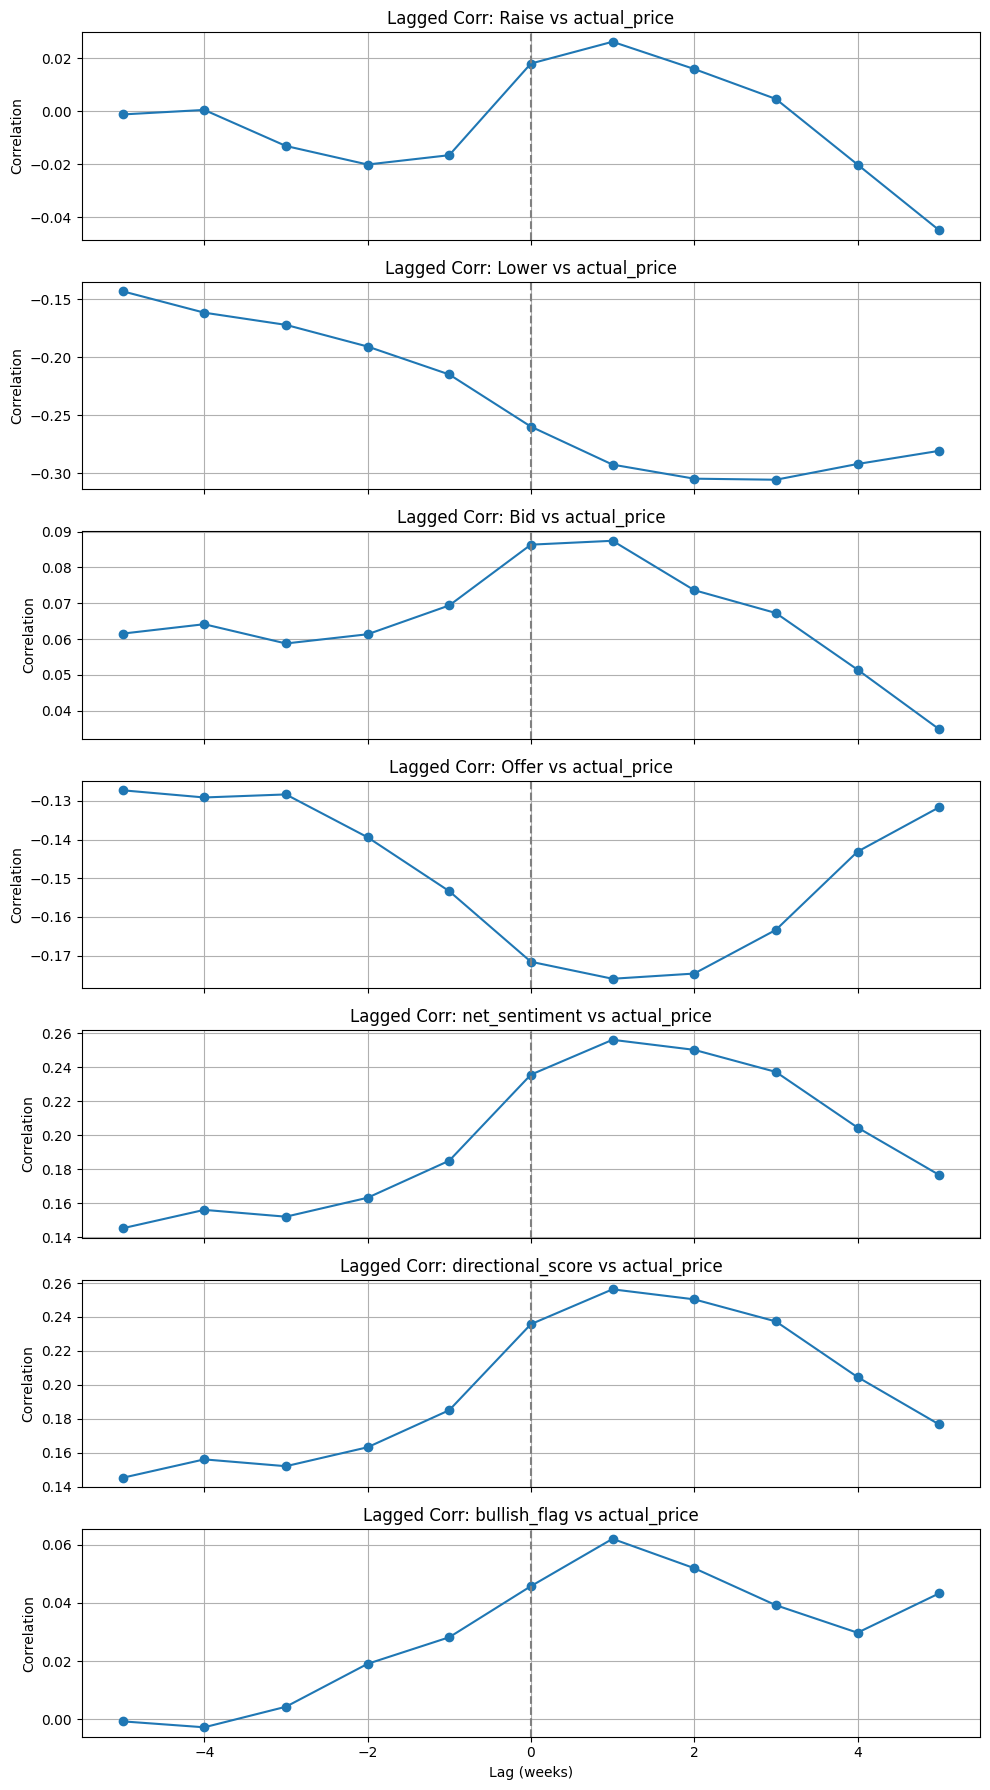

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Filter HEARDS for MOPS 380 ===
df_380 = df[df["price_basis"] == "MOPS 380"].copy()
df_380["updatedDate"] = pd.to_datetime(df_380["updatedDate"])
df_380.set_index("updatedDate", inplace=True)

# === Weekly Sentiment Counts & OTC Price ===
weekly_sentiment_380 = df_380.groupby([pd.Grouper(freq='W'), 'action_type']).size().unstack(fill_value=0)
weekly_otc_price_380 = df_380["price"].resample("W").mean().rename("otc_price")

# === Merge weekly features ===
weekly_380 = pd.concat([weekly_sentiment_380, weekly_otc_price_380], axis=1)

# === Z-score standardization ===
def zscore(series):
    return (series - series.mean()) / series.std()

weekly_380_z = weekly_380.apply(zscore)

# === Merge actual MOPS 380 price ===
weekly_380_z['actual_price'] = weekly_actual_380_trimmed.loc[weekly_380_z.index]

# === Composite sentiment features ===
weekly_380_z['net_sentiment'] = weekly_380_z['Raise'] + weekly_380_z['Bid'] - weekly_380_z['Lower'] - weekly_380_z['Offer']
weekly_380_z['directional_score'] = (
    zscore(weekly_380_z['Raise']) +
    zscore(weekly_380_z['Bid']) -
    zscore(weekly_380_z['Lower']) -
    zscore(weekly_380_z['Offer'])
)
weekly_380_z['bullish_flag'] = (
    (zscore(weekly_380_z['Raise']) > 1) &
    (zscore(weekly_380_z['Bid']) > 1) &
    (zscore(weekly_380_z['Offer']) < -0.5)
).astype(int)

# === Lagged correlation utility ===
def compute_lagged_corr(df, feature, target, max_lag=5):
    lags = range(-max_lag, max_lag + 1)
    correlations = [df[feature].shift(lag).corr(df[target]) for lag in lags]
    return list(lags), correlations

# === Analyze and plot ===
features = ['Raise', 'Lower', 'Bid', 'Offer', 'net_sentiment', 'directional_score', 'bullish_flag']
target = 'actual_price'

fig, axes = plt.subplots(len(features), 1, figsize=(10, 18), sharex=True)
for i, feature in enumerate(features):
    lags, corrs = compute_lagged_corr(weekly_380_z, feature, target)
    axes[i].plot(lags, corrs, marker='o')
    axes[i].axvline(0, linestyle='--', color='gray')
    axes[i].set_title(f"Lagged Corr: {feature} vs {target}")
    axes[i].set_ylabel("Correlation")
    axes[i].grid(True)

plt.xlabel("Lag (weeks)")
plt.tight_layout()
plt.show()


In [34]:
# === Prepare for OTC vs Actual correlation ===
weekly_otc_trimmed_380 = weekly_380_z["otc_price"]
weekly_actual_trimmed_380 = weekly_actual_380_trimmed.loc[weekly_380_z.index]
combined_price_df_380 = pd.concat([weekly_otc_trimmed_380, weekly_actual_trimmed_380], axis=1).dropna()
combined_price_df_380.columns = ["otc_price", "actual_price"]

# === Compute all correlations ===
lags = list(range(-5, 6))  # Lag range: -5 to +5

otc_vs_actual_corrs_380       = compute_lagged_corr(combined_price_df_380, "otc_price", "actual_price")
raise_vs_actual_corrs_380     = compute_lagged_corr(weekly_380_z, "Raise", "actual_price")
lower_vs_actual_corrs_380     = compute_lagged_corr(weekly_380_z, "Lower", "actual_price")
bid_vs_actual_corrs_380       = compute_lagged_corr(weekly_380_z, "Bid", "actual_price")
offer_vs_actual_corrs_380     = compute_lagged_corr(weekly_380_z, "Offer", "actual_price")
net_sentiment_corrs_380       = compute_lagged_corr(weekly_380_z, "net_sentiment", "actual_price")
directional_score_corrs_380   = compute_lagged_corr(weekly_380_z, "directional_score", "actual_price")
bullish_flag_corrs_380        = compute_lagged_corr(weekly_380_z, "bullish_flag", "actual_price")


In [35]:
# === Assemble correlation table ===
corr_table_380 = pd.DataFrame({
    "Lag (weeks)": lags,
    "OTC vs Actual": otc_vs_actual_corrs_380[1],
    "Raise vs Actual": raise_vs_actual_corrs_380[1],
    "Lower vs Actual": lower_vs_actual_corrs_380[1],
    "Bid vs Actual": bid_vs_actual_corrs_380[1],
    "Offer vs Actual": offer_vs_actual_corrs_380[1],
    "Net Sentiment vs Actual": net_sentiment_corrs_380[1],
    "Directional Score vs Actual": directional_score_corrs_380[1],
    "Bullish Flag vs Actual": bullish_flag_corrs_380[1]
})

# === Identify max correlation in lag +1 to +3 ===
lag_leads_380 = corr_table_380[corr_table_380["Lag (weeks)"].isin([1, 2, 3])]
rankings_380 = []

for column in corr_table_380.columns[1:]:
    max_corr = lag_leads_380[column].max()
    best_lag = lag_leads_380.loc[lag_leads_380[column].idxmax(), "Lag (weeks)"]
    rankings_380.append((column, max_corr, best_lag))

# === Create final ranking DataFrame ===
ranking_df_380 = pd.DataFrame(rankings_380, columns=["Feature", "Max Correlation (Lag +1 to +3)", "Best Lag"])
ranking_df_380 = ranking_df_380.sort_values(by="Max Correlation (Lag +1 to +3)", ascending=False).reset_index(drop=True)
ranking_df_380.index += 1  # Start index at 1

# === Display table ===
print(ranking_df_380.to_string(index=True))


                       Feature  Max Correlation (Lag +1 to +3)  Best Lag
1                OTC vs Actual                        0.413354         3
2      Net Sentiment vs Actual                        0.256287         1
3  Directional Score vs Actual                        0.256287         1
4                Bid vs Actual                        0.087447         1
5       Bullish Flag vs Actual                        0.062075         1
6              Raise vs Actual                        0.026320         1
7              Offer vs Actual                       -0.163339         3
8              Lower vs Actual                       -0.292374         1


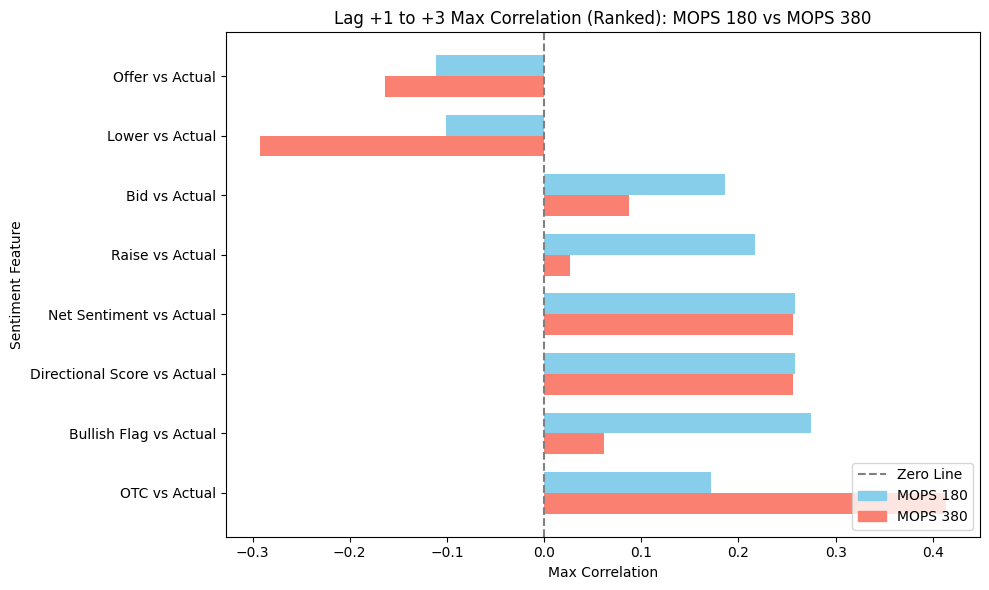

In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

# Sort by max correlation
df_combined['max_corr'] = df_combined.max(axis=1)
df_sorted = df_combined.sort_values(by='max_corr', ascending=False).drop(columns='max_corr')

# Setup
features = df_sorted.index.tolist()
y = np.arange(len(features))  # Y positions

bar_height = 0.35

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bars_180 = ax.barh(y + bar_height / 2, df_sorted["Max Correlation (MOPS 180)"],
                   height=bar_height, color='skyblue', label='MOPS 180')
bars_380 = ax.barh(y - bar_height / 2, df_sorted["Max Correlation (MOPS 380)"],
                   height=bar_height, color='salmon', label='MOPS 380')

# Zero line
ax.axvline(0, color='gray', linestyle='--')

# Y-axis labels
ax.set_yticks(y)
ax.set_yticklabels(features)

# Manual legend
legend_handles = [
    mlines.Line2D([], [], color='gray', linestyle='--', label='Zero Line'),
    mpatches.Patch(color='skyblue', label='MOPS 180'),
    mpatches.Patch(color='salmon', label='MOPS 380')
]

# Labels and layout
ax.set_title("Lag +1 to +3 Max Correlation (Ranked): MOPS 180 vs MOPS 380")
ax.set_xlabel("Max Correlation")
ax.set_ylabel("Sentiment Feature")
ax.legend(handles=legend_handles, loc="lower right")

plt.tight_layout()
plt.show()


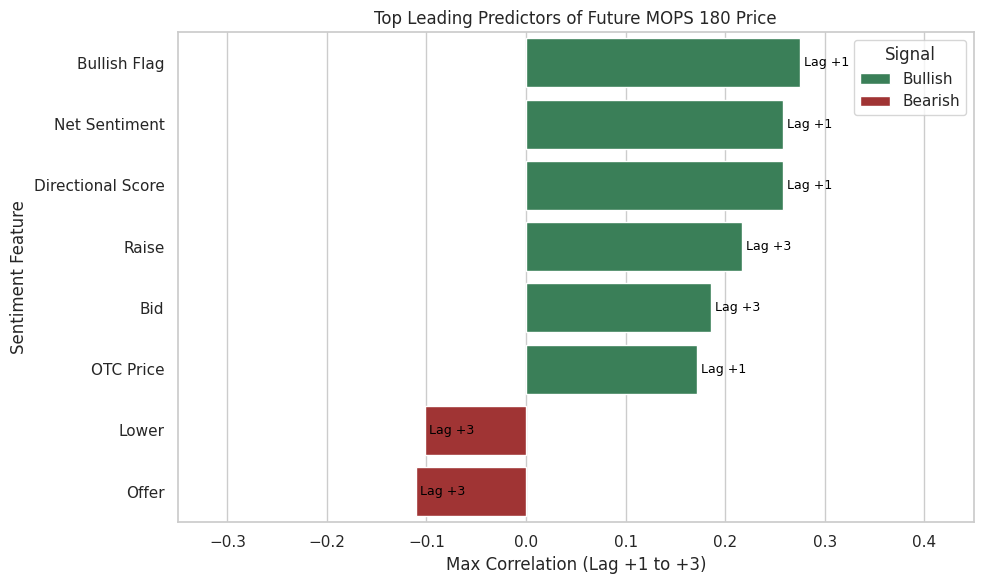

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# === MOPS 180 Data (with better feature name) ===
data_180 = {
    "Feature": [
        "Bullish Flag", "Net Sentiment", "Directional Score",
        "Raise", "Bid", "OTC Price", "Lower", "Offer"
    ],
    "Correlation": [0.275, 0.258, 0.258, 0.217, 0.186, 0.172, -0.101, -0.111],
    "Best Lag": [1, 1, 1, 3, 3, 1, 3, 3],
    "Signal": ["Bullish", "Bullish", "Bullish", "Bullish", "Bullish", "Bullish", "Bearish", "Bearish"]
}
df_180 = pd.DataFrame(data_180)
df_180 = df_180[df_180["Best Lag"] >= 1].sort_values(by="Correlation", ascending=False)

# === Plot for MOPS 180 ===
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Correlation", y="Feature", data=df_180,
    hue="Signal", dodge=False, palette={"Bullish": "seagreen", "Bearish": "firebrick"}
)
for i, row in df_180.iterrows():
    plt.text(row["Correlation"], i, f" Lag +{row['Best Lag']}", va='center', ha='left', fontsize=9, color='black')

plt.title("Top Leading Predictors of Future MOPS 180 Price")
plt.xlim(-0.35, 0.45)
plt.xlabel("Max Correlation (Lag +1 to +3)")
plt.ylabel("Sentiment Feature")
plt.legend(title="Signal")
plt.tight_layout()
plt.show()


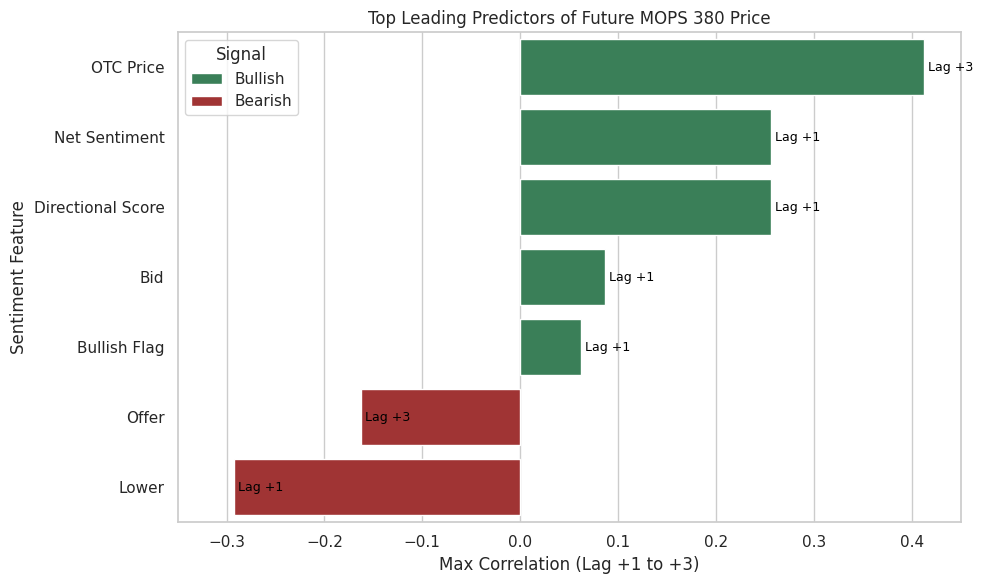

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# === MOPS 380 Data (renamed) ===
data_380 = {
    "Feature": [
        "OTC Price", "Net Sentiment", "Directional Score",
        "Bid", "Bullish Flag", "Offer", "Lower"
    ],
    "Correlation": [0.413, 0.256, 0.256, 0.087, 0.062, -0.163, -0.292],
    "Best Lag": [3, 1, 1, 1, 1, 3, 1],
    "Signal": ["Bullish", "Bullish", "Bullish", "Bullish", "Bullish", "Bearish", "Bearish"]
}
df_380 = pd.DataFrame(data_380)
df_380 = df_380[df_380["Best Lag"] >= 1].sort_values(by="Correlation", ascending=False)

# === Plot for MOPS 380 ===
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Correlation", y="Feature", data=df_380,
    hue="Signal", dodge=False, palette={"Bullish": "seagreen", "Bearish": "firebrick"}
)
for i, row in df_380.iterrows():
    plt.text(row["Correlation"], i, f" Lag +{row['Best Lag']}", va='center', ha='left', fontsize=9, color='black')

plt.title("Top Leading Predictors of Future MOPS 380 Price")
plt.xlim(-0.35, 0.45)
plt.xlabel("Max Correlation (Lag +1 to +3)")
plt.ylabel("Sentiment Feature")
plt.legend(title="Signal")
plt.tight_layout()
plt.show()


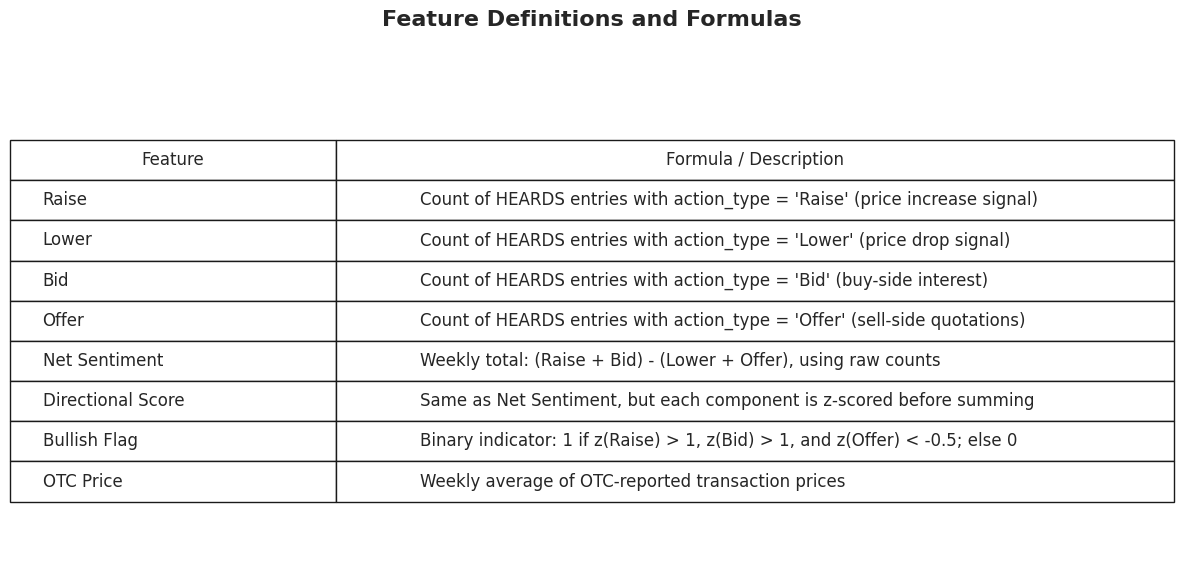

In [60]:
import matplotlib.pyplot as plt

# === Final updated content ===
features = [
    "Raise", "Lower", "Bid", "Offer",
    "Net Sentiment",
    "Directional Score",
    "Bullish Flag",
    "OTC Price"
]

descriptions = [
    "Count of HEARDS entries with action_type = 'Raise' (price increase signal)",
    "Count of HEARDS entries with action_type = 'Lower' (price drop signal)",
    "Count of HEARDS entries with action_type = 'Bid' (buy-side interest)",
    "Count of HEARDS entries with action_type = 'Offer' (sell-side quotations)",
    "Weekly total: (Raise + Bid) - (Lower + Offer), using raw counts",
    "Same as Net Sentiment, but each component is z-scored before summing",
    "Binary indicator: 1 if z(Raise) > 1, z(Bid) > 1, and z(Offer) < -0.5; else 0",
    "Weekly average of OTC-reported transaction prices"
]

# === Create table ===
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

table_data = list(zip(features, descriptions))
table = plt.table(
    cellText=table_data,
    colLabels=["Feature", "Formula / Description"],
    cellLoc='left',
    loc='center',
    colWidths=[0.28, 0.72]
)

# === Style ===
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2.2)

plt.title("Feature Definitions and Formulas", fontsize=16, weight='bold', pad=30)

plt.tight_layout()
plt.show()


## 🔁 Daily Correlation Analysis

Now that we have completed our weekly analysis of sentiment features and their correlation with benchmark prices (MOPS 180 and MOPS 380), we will repeat the core analysis at **daily frequency**.

This is essential because:

- Our raw data (HEARDS sentiment and OTC prices) was originally at a **daily resolution**.
- Weekly resampling may have smoothed or delayed signal responses.
- For practical trading or forecasting applications, **daily granularity** offers sharper insights and higher signal precision.

### What We Will Do:

1. **Recompute sentiment features** at the **daily level** for both MOPS 180 and MOPS 380.
2. **Recalculate correlation analysis** between these features and the daily benchmark prices.
3. **Visualize**:
   - Lagged correlation rankings (daily)
   - Bullish/bearish leading indicators (daily)
   - Indicator formula table (daily context)

We will proceed with an **expedited version** of the weekly analysis pipeline, keeping key visualizations and insights intact.


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load HEARDS dataset
df = pd.read_csv("heards_structured_cleaned_v11.csv", parse_dates=["updatedDate"])

# Load actual MOPS 180 benchmark price data
df_actual_180 = pd.read_csv("CI_SymbolPrice_2025-06-02T030821Z.csv")
df_actual_180 = df_actual_180.rename(columns={
    "Description": "Date",
    "FO 180 CST 3.5%S FOB Spore Cargo": "Close"
})
df_actual_180 = df_actual_180[~df_actual_180["Date"].str.contains("Currency|Symbol|Bate", na=False)]
df_actual_180["Date"] = pd.to_datetime(df_actual_180["Date"])
df_actual_180["Close"] = pd.to_numeric(df_actual_180["Close"], errors="coerce")
df_actual_180.set_index("Date", inplace=True)
df_actual_180 = df_actual_180["Close"]  # Just the Close column, indexed by Date


In [64]:
# Filter for MOPS 180
df_180 = df[df["price_basis"] == "MOPS 180"].copy()
df_180["updatedDate"] = pd.to_datetime(df_180["updatedDate"])
df_180.set_index("updatedDate", inplace=True)

# Group sentiment counts and average OTC price daily
daily_sentiment_180 = df_180.groupby([pd.Grouper(freq="D"), "action_type"]).size().unstack(fill_value=0)
daily_otc_price_180 = df_180["price"].resample("D").mean().rename("otc_price")

# Combine sentiment + price
daily_180 = pd.concat([daily_sentiment_180, daily_otc_price_180], axis=1)


In [66]:
# === Standardize all columns using z-score ===
def zscore(series):
    return (series - series.mean()) / series.std()

daily_180_z = daily_180.apply(zscore)

# === Align to common dates only to avoid KeyError ===
# Some dates exist in OTC data but not in actual price data, so we intersect them
common_dates = daily_180_z.index.intersection(df_actual_180.index)

# Subset both datasets to only those dates
daily_180_z = daily_180_z.loc[common_dates]
df_actual_180_trimmed = df_actual_180.loc[common_dates]

# Add the actual MOPS 180 price as a new column
daily_180_z["actual_price"] = df_actual_180_trimmed


In [67]:
# === Composite sentiment features ===
daily_180_z["net_sentiment"] = (
    daily_180_z["Raise"] +
    daily_180_z["Bid"] -
    daily_180_z["Lower"] -
    daily_180_z["Offer"]
)

daily_180_z["directional_score"] = (
    zscore(daily_180_z["Raise"]) +
    zscore(daily_180_z["Bid"]) -
    zscore(daily_180_z["Lower"]) -
    zscore(daily_180_z["Offer"])
)

daily_180_z["bullish_flag"] = (
    (zscore(daily_180_z["Raise"]) > 1) &
    (zscore(daily_180_z["Bid"]) > 1) &
    (zscore(daily_180_z["Offer"]) < -0.5)
).astype(int)


In [68]:
def compute_lagged_corr(df, feature, target, max_lag=5):
    lags = range(-max_lag, max_lag + 1)
    correlations = [df[feature].shift(lag).corr(df[target]) for lag in lags]
    return list(lags), correlations

features = ["Raise", "Lower", "Bid", "Offer", "net_sentiment", "directional_score", "bullish_flag"]
target = "actual_price"
lags = list(range(-5, 6))

# Collect correlation results
results_180 = []
for feature in features:
    _, corrs = compute_lagged_corr(daily_180_z, feature, target)
    results_180.append((feature, corrs))

# Build correlation table
corr_table_180 = pd.DataFrame({"Lag (days)": lags})
for feature, corrs in results_180:
    corr_table_180[f"{feature} vs Actual"] = corrs


In [69]:
# Extract lag +1 to +3 correlations and rank them
lead_lags = corr_table_180[corr_table_180["Lag (days)"].isin([1, 2, 3])]
ranking_180 = []

for column in corr_table_180.columns[1:]:
    max_corr = lead_lags[column].max()
    best_lag = lead_lags.loc[lead_lags[column].idxmax(), "Lag (days)"]
    ranking_180.append((column.replace(" vs Actual", ""), max_corr, best_lag))

ranking_df_180 = pd.DataFrame(ranking_180, columns=["Feature", "Max Correlation (Lag +1 to +3)", "Best Lag"])
ranking_df_180 = ranking_df_180.sort_values(by="Max Correlation (Lag +1 to +3)", ascending=False).reset_index(drop=True)
ranking_df_180.index += 1

# Display the ranked table
ranking_df_180


,Feature,Max Correlation (Lag +1 to +3),Best Lag
1,net_sentiment,0.221314,2
2,directional_score,0.221313,2
3,Raise,0.181719,2
4,bullish_flag,0.159619,3
5,Bid,0.147385,2
6,Lower,-0.099558,1
7,Offer,-0.133263,3


In [71]:
# Store MOPS 180 results for comparison plot
df_daily_180_summary = ranking_df_180[["Feature", "Max Correlation (Lag +1 to +3)"]].copy()
df_daily_180_summary.columns = ["Feature", "Max Correlation (MOPS 180)"]


In [72]:
# Show full correlation table across -5 to +5 lags
import pandas as pd
corr_table_180.round(3)  # Already created in Step 5


,Lag (days),Raise vs Actual,Lower vs Actual,Bid vs Actual,Offer vs Actual,net_sentiment vs Actual,directional_score vs Actual,bullish_flag vs Actual
0,-5,0.134,-0.070,0.114,-0.131,0.175,0.175,0.133
1,-4,0.136,-0.075,0.118,-0.134,0.180,0.180,0.138
2,-3,0.141,-0.076,0.124,-0.135,0.186,0.186,0.138
3,-2,0.148,-0.081,0.132,-0.135,0.193,0.193,0.144
4,-1,0.158,-0.083,0.139,-0.133,0.200,0.200,0.149
5,0,0.173,-0.091,0.145,-0.135,0.212,0.212,0.155
6,1,0.179,-0.100,0.147,-0.138,0.220,0.220,0.156
7,2,0.182,-0.103,0.147,-0.136,0.221,0.221,0.158
8,3,0.182,-0.103,0.147,-0.133,0.220,0.220,0.160
9,4,0.182,-0.102,0.149,-0.129,0.219,0.219,0.154


In [73]:
# Load actual MOPS 380 benchmark price
df_actual_380 = pd.read_csv("CI_SymbolPrice_2025-06-02T030407Z.csv")
df_actual_380 = df_actual_380.rename(columns={
    "Description": "Date",
    "FO 380 CST 3.5%S FOB Spore Cargo": "Close"
})
df_actual_380 = df_actual_380[~df_actual_380["Date"].str.contains("Currency|Symbol|Bate", na=False)]
df_actual_380["Date"] = pd.to_datetime(df_actual_380["Date"])
df_actual_380["Close"] = pd.to_numeric(df_actual_380["Close"], errors="coerce")
df_actual_380.set_index("Date", inplace=True)
df_actual_380 = df_actual_380["Close"]


In [74]:
# Filter HEARDS for MOPS 380
df_380 = df[df["price_basis"] == "MOPS 380"].copy()
df_380["updatedDate"] = pd.to_datetime(df_380["updatedDate"])
df_380.set_index("updatedDate", inplace=True)

# Daily sentiment counts and OTC price
daily_sentiment_380 = df_380.groupby([pd.Grouper(freq="D"), "action_type"]).size().unstack(fill_value=0)
daily_otc_price_380 = df_380["price"].resample("D").mean().rename("otc_price")

# Combine into single dataframe
daily_380 = pd.concat([daily_sentiment_380, daily_otc_price_380], axis=1)


In [75]:
# Z-score standardization
def zscore(series):
    return (series - series.mean()) / series.std()

daily_380_z = daily_380.apply(zscore)

# Align to overlapping dates to prevent KeyError
common_dates = daily_380_z.index.intersection(df_actual_380.index)
daily_380_z = daily_380_z.loc[common_dates]
daily_380_z["actual_price"] = df_actual_380.loc[common_dates]


In [76]:
daily_380_z["net_sentiment"] = (
    daily_380_z["Raise"] +
    daily_380_z["Bid"] -
    daily_380_z["Lower"] -
    daily_380_z["Offer"]
)

daily_380_z["directional_score"] = (
    zscore(daily_380_z["Raise"]) +
    zscore(daily_380_z["Bid"]) -
    zscore(daily_380_z["Lower"]) -
    zscore(daily_380_z["Offer"])
)

daily_380_z["bullish_flag"] = (
    (zscore(daily_380_z["Raise"]) > 1) &
    (zscore(daily_380_z["Bid"]) > 1) &
    (zscore(daily_380_z["Offer"]) < -0.5)
).astype(int)


In [77]:
def compute_lagged_corr(df, feature, target, max_lag=5):
    lags = range(-max_lag, max_lag + 1)
    correlations = [df[feature].shift(lag).corr(df[target]) for lag in lags]
    return list(lags), correlations

features_380 = ["Raise", "Lower", "Bid", "Offer", "net_sentiment", "directional_score", "bullish_flag"]
target = "actual_price"
lags_380 = list(range(-5, 6))

results_380 = []
for feature in features_380:
    _, corrs = compute_lagged_corr(daily_380_z, feature, target)
    results_380.append((feature, corrs))

# Build full correlation table
corr_table_380 = pd.DataFrame({"Lag (days)": lags_380})
for feature, corrs in results_380:
    corr_table_380[f"{feature} vs Actual"] = corrs


In [78]:
# Rank based on lags +1 to +3
lead_lags_380 = corr_table_380[corr_table_380["Lag (days)"].isin([1, 2, 3])]
ranking_380 = []

for column in corr_table_380.columns[1:]:
    max_corr = lead_lags_380[column].max()
    best_lag = lead_lags_380.loc[lead_lags_380[column].idxmax(), "Lag (days)"]
    ranking_380.append((column.replace(" vs Actual", ""), max_corr, best_lag))

ranking_df_380 = pd.DataFrame(ranking_380, columns=["Feature", "Max Correlation (Lag +1 to +3)", "Best Lag"])
ranking_df_380 = ranking_df_380.sort_values(by="Max Correlation (Lag +1 to +3)", ascending=False).reset_index(drop=True)
ranking_df_380.index += 1

# Display the ranked predictors
ranking_df_380


,Feature,Max Correlation (Lag +1 to +3),Best Lag
1,directional_score,0.214585,1
2,net_sentiment,0.214583,1
3,Bid,0.076073,1
4,bullish_flag,0.057523,1
5,Raise,0.022989,1
6,Offer,-0.153751,3
7,Lower,-0.248209,1


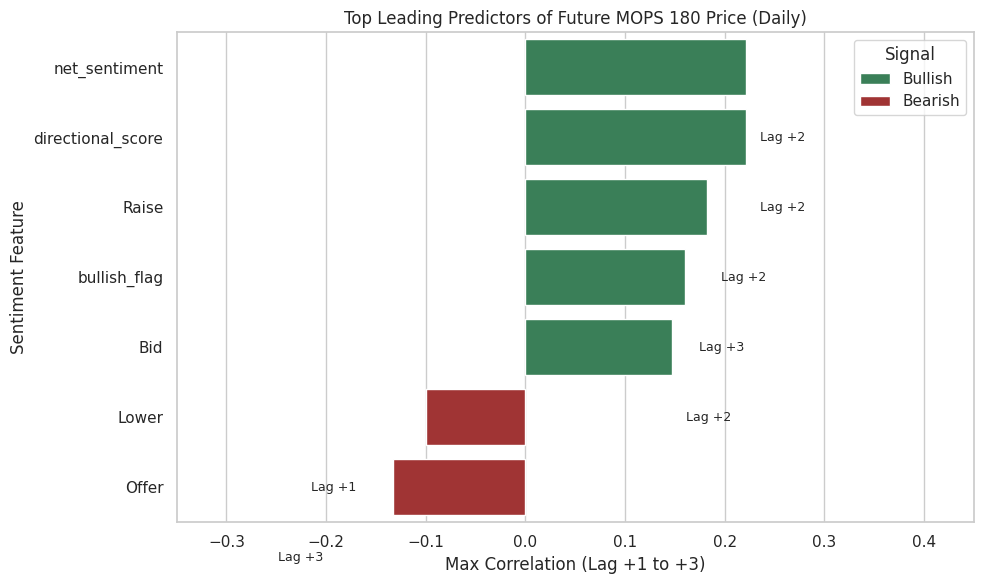

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# Assign signal label
ranking_df_180["Signal"] = ranking_df_180["Feature"].apply(
    lambda x: "Bearish" if x in ["Lower", "Offer"] else "Bullish"
)

# Plot setup
plt.figure(figsize=(10, 6))
sns.barplot(
    data=ranking_df_180,
    x="Max Correlation (Lag +1 to +3)",
    y="Feature",
    hue="Signal",
    dodge=False,
    palette={"Bullish": "seagreen", "Bearish": "firebrick"}
)

# Annotate each bar with lag value
for i, row in ranking_df_180.iterrows():
    x = row["Max Correlation (Lag +1 to +3)"]
    offset = 0.01 if x >= 0 else -0.07
    align = "left" if x >= 0 else "right"

    plt.text(
        x + offset,
        i,
        f" Lag +{row['Best Lag']}",
        va="center",
        ha=align,
        fontsize=9
    )

# Labels and layout
plt.title("Top Leading Predictors of Future MOPS 180 Price (Daily)")
plt.xlim(-0.35, 0.45)
plt.xlabel("Max Correlation (Lag +1 to +3)")
plt.ylabel("Sentiment Feature")
plt.legend(title="Signal")
plt.tight_layout()
plt.show()


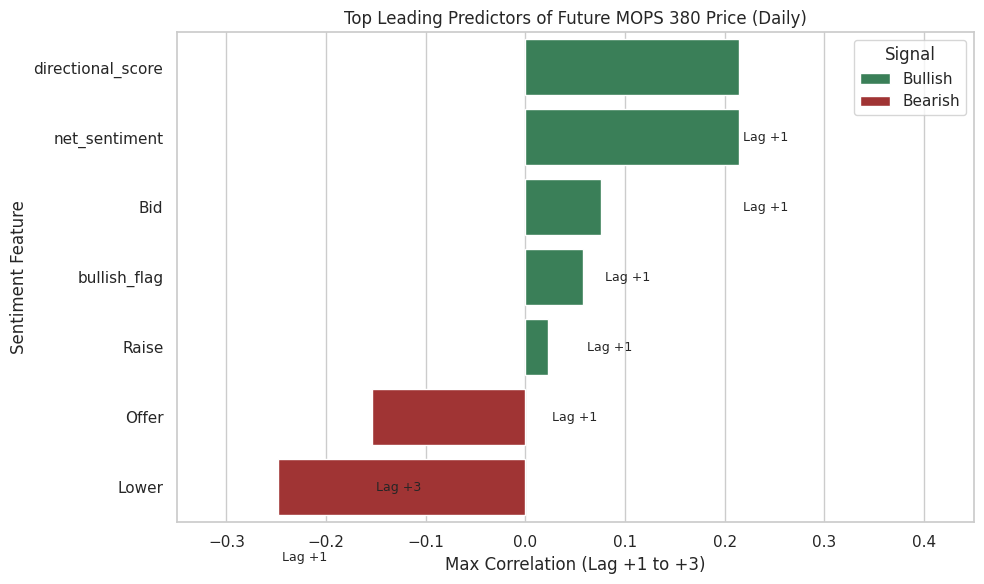

In [79]:
import seaborn as sns
sns.set(style="whitegrid")

# Add signal type
ranking_df_380["Signal"] = ranking_df_380["Feature"].apply(
    lambda x: "Bearish" if x in ["Lower", "Offer"] else "Bullish"
)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=ranking_df_380,
    x="Max Correlation (Lag +1 to +3)",
    y="Feature",
    hue="Signal",
    dodge=False,
    palette={"Bullish": "seagreen", "Bearish": "firebrick"}
)

# Annotate lag values
for i, row in ranking_df_380.iterrows():
    plt.text(
        row["Max Correlation (Lag +1 to +3)"],
        i,
        f" Lag +{row['Best Lag']}",
        va="center",
        ha="left",
        fontsize=9
    )

plt.title("Top Leading Predictors of Future MOPS 380 Price (Daily)")
plt.xlim(-0.35, 0.45)
plt.xlabel("Max Correlation (Lag +1 to +3)")
plt.ylabel("Sentiment Feature")
plt.legend(title="Signal")
plt.tight_layout()
plt.show()


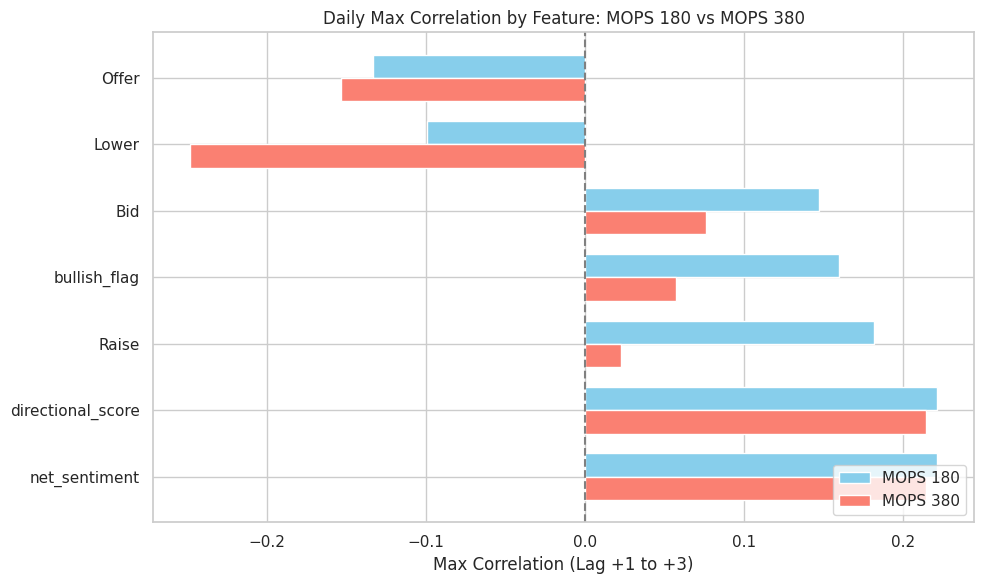

In [80]:
# Prepare MOPS 380 data for merge
df_daily_380_summary = ranking_df_380[["Feature", "Max Correlation (Lag +1 to +3)"]].copy()
df_daily_380_summary.columns = ["Feature", "Max Correlation (MOPS 380)"]

# Merge both on Feature name
df_combined = pd.merge(df_daily_180_summary, df_daily_380_summary, on="Feature", how="outer")
df_combined.set_index("Feature", inplace=True)

# Sort by max of either value
df_combined["max_corr"] = df_combined.max(axis=1)
df_sorted = df_combined.sort_values(by="max_corr", ascending=False).drop(columns="max_corr")

# Plot
features = df_sorted.index.tolist()
y = np.arange(len(features))
bar_height = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(y + bar_height/2, df_sorted["Max Correlation (MOPS 180)"], height=bar_height, label="MOPS 180", color="skyblue")
ax.barh(y - bar_height/2, df_sorted["Max Correlation (MOPS 380)"], height=bar_height, label="MOPS 380", color="salmon")

ax.set_yticks(y)
ax.set_yticklabels(features)
ax.axvline(0, color="gray", linestyle="--")
ax.set_xlabel("Max Correlation (Lag +1 to +3)")
ax.set_title("Daily Max Correlation by Feature: MOPS 180 vs MOPS 380")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


In [83]:
import pandas as pd

# === STEP 1: Load the correct dataset ===
df = pd.read_csv("heards_structured_cleaned_v11.csv", parse_dates=["updatedDate", "start_date"])

# === STEP 2: Filter for MOPS 180 and MOPS 380 only ===
df = df[df["price_basis"].isin(["MOPS 180", "MOPS 380"])]

# === STEP 3: Group by start_date and price_basis ===
daily_grouped = df.groupby(["start_date", "price_basis"])

# === STEP 4: Count action types ===
daily_counts = daily_grouped["action_type"].value_counts().unstack(fill_value=0)
daily_counts.columns = [f"{col}_count_daily" for col in daily_counts.columns]

# === STEP 5: Compute net_sentiment_daily ===
daily_counts["net_sentiment_daily"] = (
    daily_counts.get("Raise_count_daily", 0)
    + daily_counts.get("Bid_count_daily", 0)
    - daily_counts.get("Lower_count_daily", 0)
    - daily_counts.get("Offer_count_daily", 0)
)

# === STEP 6: Compute z-scores per price_basis group ===
z_df = daily_counts.groupby("price_basis")[[
    "Raise_count_daily", "Lower_count_daily", "Bid_count_daily", "Offer_count_daily"
]].transform(lambda x: (x - x.mean()) / x.std(ddof=0))

# === STEP 7: Compute directional_score_daily ===
daily_counts["directional_score_daily"] = (
    z_df["Raise_count_daily"]
    + z_df["Bid_count_daily"]
    - z_df["Lower_count_daily"]
    - z_df["Offer_count_daily"]
)

# === STEP 8: Compute bullish_flag_daily ===
daily_counts["bullish_flag_daily"] = (
    (z_df["Raise_count_daily"] > 1)
    & (z_df["Bid_count_daily"] > 1)
    & (z_df["Offer_count_daily"] < -0.5)
).astype(int)

# === STEP 9: Calculate average OTC price per day ===
daily_price = daily_grouped["price"].mean().rename("otc_price_daily")

# === STEP 10: Merge all indicators ===
final_daily_df = daily_counts.join(daily_price).reset_index()

# === STEP 11: Save to CSV ===
final_daily_df.to_csv("daily_indicators.csv", index=False)

# === STEP 12: Download the file in Colab ===
from google.colab import files
files.download("daily_indicators.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [85]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("heards_structured_cleaned_v11.csv", parse_dates=["start_date"])

# Filter valid rows
df = df.dropna(subset=["price", "price_basis", "start_date"])

# Set start of each week (Monday)
df["week_start"] = df["start_date"] - pd.to_timedelta(df["start_date"].dt.weekday, unit="d")

# === Step 1: Compute Weekly OTC Price ===
weekly_price = df.groupby(["week_start", "price_basis"])["price"].mean().reset_index(name="otc_price_weekly")

# === Step 2: Compute Weekly Indicators ===
def compute_weekly_flags(group):
    raise_flag = (group["action_type"].str.lower() == "raise").any()
    lower_flag = (group["action_type"].str.lower() == "lower").any()
    bid_flag = (group["action_type"].str.lower() == "bid").any()
    offer_flag = (group["action_type"].str.lower() == "offer").any()

    result = {
        "Raise_weekly": raise_flag,
        "Lower_weekly": lower_flag,
        "Bid_weekly": bid_flag,
        "Offer_weekly": offer_flag,
        "bullish_flag_weekly": raise_flag or bid_flag,
        "net_sentiment_weekly": int(raise_flag) + int(bid_flag) - int(lower_flag) - int(offer_flag),
        "directional_score_weekly": int(raise_flag) + int(bid_flag)
    }

    return pd.Series(result)

weekly_indicators = df.groupby(["week_start", "price_basis"]).apply(compute_weekly_flags).reset_index()

# === Step 3: Merge and Save ===
df_weekly = pd.merge(weekly_price, weekly_indicators, on=["week_start", "price_basis"])
df_weekly.to_csv("weekly_indicators.csv", index=False)

# Optional: Download CSV in Colab
from google.colab import files
files.download("weekly_indicators.csv")


<ipython-input-85-1be178f3c824>:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly_indicators = df.groupby(["week_start", "price_basis"]).apply(compute_weekly_flags).reset_index()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>